In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

https://stackoverflow.com/questions/79490818/function-with-two-variables-polynomial-fit-python

In [3]:
data = pd.DataFrame({
    'Flow(lpm)': [128.0846942, 105.7579874, 95.11146262, 69.57902038, 53.25344504, 35.47260492, np.nan, 131.96, 110.57, 91.32, 73.02, 53.9, 20.41, np.nan, 116.06, 99.46, 83.7, 68.84, 54.47, 20.98, np.nan, 103.0, 87.6, 73.6, 57.8, 44.0, 19.49, np.nan, 86.2, 73.1, 56.0, 42.6, 28.1, 16.33, np.nan, 56.2, 47.1, 38.6, 30.9, 24.0, 12.3],
    'Speed Feedback (RPM)': [5204.0, 5208.0, 5206.0, 5206.0, 5176.0, 5175.0, np.nan, 4710.72, 4706.4, 4714.93, 4687.11, 4691.0, 4602.0, np.nan, 4103.21, 4115.26, 4147.8, 4148.14, 4141.09, 4124.72, np.nan, 3675.89, 3657.88, 3673.73, 3671.41, 3675.27, 3664.88, np.nan, 3118.66, 3186.23, 3106.92, 3107.19, 3114.69, 3090.08, np.nan, 2077.44, 2073.23, 2062.01, 2069.37, 2068.02, 2067.91],
    'dP (PSI)': [16.5, 25.34, 28.78, 35.45, 37.86, 38.87, np.nan, 8.85, 17.01, 23.42, 27.48, 30.5, 32.4, np.nan, 6.69, 11.84, 17.24, 20.16, 22.64, 25.81, np.nan, 5.2, 9.6, 13.2, 16.3, 18.1, 20.38, np.nan, 3.7, 6.5, 10.0, 12.1, 13.5, 14.54, np.nan, 1.2, 2.7, 3.7, 4.7, 5.2, 6.3]
})

In [5]:
data = data.dropna()

In [19]:
def model(x, a, b, c, d, e, f):
    return a * x[:,0] ** 2 + b * x[:,0] + c * x[:,1] ** 2 + d * x[:,1] + e * x[:,0] * x[:,1] + f

In [21]:
popt, pcov = optimize.curve_fit(model, data.iloc[:,:2].values, data.iloc[:,2].values)

In [23]:
popt

array([-1.69481758e-03, -1.08681275e-02,  1.25567325e-06,  1.99560411e-03,
        9.22107316e-06, -3.57414054e+00])

In [25]:
x0lin = np.linspace(data.iloc[:,0].min(), data.iloc[:,0].max(), 200)
x1lin = np.linspace(data.iloc[:,1].min(), data.iloc[:,1].max(), 200)
X0, X1 = np.meshgrid(x0lin, x1lin)

In [33]:
Z = model(np.array([X0.ravel(), X1.ravel()]).T, *popt).reshape(X0.shape)

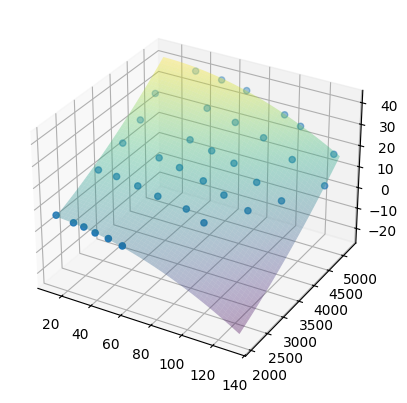

In [38]:
fig, axe = plt.subplots(subplot_kw={"projection": "3d"})
axe.scatter(*data.values.T)
axe.plot_surface(X0, X1, Z, cmap="viridis", alpha=0.35)